In [1]:
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
from openai import OpenAI
openai_client = OpenAI()

In [3]:
def llm(prompt):
    response = openai_client.responses.create(
        model="gpt-5.4-mini",
        input=prompt
    )
    return response.output_text

In [4]:
question = "I just discovered the course. Can I join now?"
answer = llm(question)
print(answer)

Usually, yes—if the course is still open and there’s no fixed start or enrollment deadline.

A few things to check:
- **Enrollment deadline**: Some courses allow late joins, others don’t.
- **Access to past material**: You may or may not get recordings, notes, or previous assignments.
- **Practical fit**: If it’s already underway, you might need to catch up quickly.

If you want, I can help you draft a short message to the instructor asking if late enrollment is possible.


In [5]:
context="""
I just discovered the course. Can I still join?
Yes, but if you want to receive a certificate, you need to submit your project while we're still accepting submissions.

Course: I have registered for the LLM Zoomcamp. When can I expect to receive the confirmation email?
You don't need it. You're accepted. You can also just start learning and submitting homework (while the form is open) without registering. It is not checked against any registered list. Registration is just to gauge interest before the start date.

What is the video/zoom link to the stream for the "Office Hours" or live/workshop sessions?
The zoom link is only published to instructors/presenters/TAs. Students participate via YouTube Live and submit questions to Slido.

Cloud alternatives with GPU
Check the quota and reset cycle carefully. Potential options include Google Colab, Kaggle, Databricks.
"""

In [6]:
prompt = f"""
Your task is to answer questions from the course participants
based on the provided context.

Use the context to find relevant information and provide accurate
answers. If the answer is not found in the context,
respond with "I don't know."

Question:
{question}

Context:
{context}
"""

In [7]:
print(prompt)


Your task is to answer questions from the course participants
based on the provided context.

Use the context to find relevant information and provide accurate
answers. If the answer is not found in the context,
respond with "I don't know."

Question:
I just discovered the course. Can I join now?

Context:

I just discovered the course. Can I still join?
Yes, but if you want to receive a certificate, you need to submit your project while we're still accepting submissions.

Course: I have registered for the LLM Zoomcamp. When can I expect to receive the confirmation email?
You don't need it. You're accepted. You can also just start learning and submitting homework (while the form is open) without registering. It is not checked against any registered list. Registration is just to gauge interest before the start date.

What is the video/zoom link to the stream for the "Office Hours" or live/workshop sessions?
The zoom link is only published to instructors/presenters/TAs. Students partici

In [8]:
answer = llm(prompt)
print(answer)

Yes, you can still join now. If you want to receive a certificate, you need to submit your project while submissions are still being accepted.


What we just did was naive. I knew in advance which FAQ entry held the answer and pasted it in by hand. What we want instead is to perform search automatically. We take the student's question, find the most relevant documents, and send those to the LLM.

In code, it looks like this:

In [9]:
def rag(question):
    search_results = search(question)
    user_prompt = build_prompt(question, search_results)
    return llm(user_prompt)

https://datatalksclub.github.io/faq/json/llm-zoomcamp.json

In [10]:
import requests

docs_url = "https://datatalks.club/faq/json/courses.json"
response = requests.get(docs_url)
courses_raw = response.json()

In [11]:
documents = []
url_prefix = "https://datatalks.club/faq"

for course in courses_raw:
    course_url = f"""{url_prefix}{course["path"]}"""

    course_response = requests.get(course_url)
    course_response.raise_for_status()
    course_data = course_response.json()

    documents.extend(course_data)

len(documents)

1400

In [12]:
documents[1000]

{'id': '641aedbbf5',
 'course': 'llm-zoomcamp',
 'section': 'Module 5: Monitoring',
 'question': 'How set Pandas to show entire text content in a column. Useful to view the entire Explanation column content in the LLM-as-judge section of the offline-rag-evaluation notebook',
 'answer': 'By default, Pandas truncates text content in a column to 50 characters. To view the entire explanation provided by the judge LLM for a non-relevant answer, use the following instruction:\n\n```python\npd.set_option(\'display.max_colwidth\', None)\n```\n\n- **Option:** `display.max_colwidth`\n- **Type:** `int` or `None`\n- **Description:** Sets the maximum width in characters of a column in the representation of a pandas data structure. When a column overflows, a "..." placeholder is used in the output. Setting it to \'None\' allows unlimited width.\n- **Default:** 50\n\nRefer to the [official documentation](https://pandas.pydata.org/docs/user_guide/options.html) for more details.\n\n<{IMAGE:image_1}>'}

In [13]:
from minsearch import Index

index = Index(
    text_fields=["question", "section", "answer"],
    keyword_fields=["course"]
)

index.fit(documents)

In [14]:
question = "I just discovered the course. Can I join now?"

search_results = index.search(
    question,
    boost_dict={"question": 2.0, "section": 0.5},
    filter_dict={"course": "llm-zoomcamp"},
    num_results=5
)

search_results

[{'id': '74eb249bbf',
  'course': 'llm-zoomcamp',
  'section': 'General Course-Related Questions',
  'question': 'I just discovered the course. Can I still join?',
  'answer': 'Yes, but if you want to receive a certificate, you need to submit your project while we’re still accepting submissions.'},
 {'id': '977bf7786c',
  'course': 'llm-zoomcamp',
  'section': 'General Course-Related Questions',
  'question': 'Course: I have registered for the LLM Zoomcamp. When can I expect to receive the confirmation email?',
  'answer': "You don't need it. You're accepted. You can also just start learning and submitting homework (while the form is open) without registering. It is not checked against any registered list. Registration is just to gauge interest before the start date."},
 {'id': '5cc511f85b',
  'course': 'llm-zoomcamp',
  'section': 'General Course-Related Questions',
  'question': 'Does the course certificate show the number of course hours?',
  'answer': 'No. The certificate does not 

Wrapping it in a function

In [15]:
def search(question, course="llm-zoomcamp"):
    boost_dict = {"question": 2.0, "section": 0.5}
    filter_dict = {"course": course}

    return index.search(
        question,
        boost_dict=boost_dict,
        filter_dict=filter_dict,
        num_results=5
    )

In [16]:
question = "I just discovered the course. Can I join now?"
search_results = search(question)

In [17]:
search_results

[{'id': '74eb249bbf',
  'course': 'llm-zoomcamp',
  'section': 'General Course-Related Questions',
  'question': 'I just discovered the course. Can I still join?',
  'answer': 'Yes, but if you want to receive a certificate, you need to submit your project while we’re still accepting submissions.'},
 {'id': '977bf7786c',
  'course': 'llm-zoomcamp',
  'section': 'General Course-Related Questions',
  'question': 'Course: I have registered for the LLM Zoomcamp. When can I expect to receive the confirmation email?',
  'answer': "You don't need it. You're accepted. You can also just start learning and submitting homework (while the form is open) without registering. It is not checked against any registered list. Registration is just to gauge interest before the start date."},
 {'id': '5cc511f85b',
  'course': 'llm-zoomcamp',
  'section': 'General Course-Related Questions',
  'question': 'Does the course certificate show the number of course hours?',
  'answer': 'No. The certificate does not 

In [18]:
[doc["question"] for doc in search_results]

['I just discovered the course. Can I still join?',
 'Course: I have registered for the LLM Zoomcamp. When can I expect to receive the confirmation email?',
 'Does the course certificate show the number of course hours?',
 "Why do we need orchestration / Kestra — can't I just run the code in a notebook?",
 'Certificate: Can I follow the course in a self-paced mode and get a certificate?']

When we build AI systems, we usually split the prompt into two parts:

- Instructions (also called the system prompt): this tells the LLM how to behave. It never changes, so it's the same for every request.
- User prompt: this changes with every request. It carries the actual question and the retrieved context.
We split them because the instructions are fixed and the user prompt is not. Keeping them apart makes the fixed part easy to reuse and the changing part easy to build fresh each time.



In [19]:
INSTRUCTIONS = """
Your task is to answer questions from the course participants
based on the provided context.

Use the context to find relevant information and provide accurate
answers. If the answer is not found in the context,
respond with "I don't know."
"""

The user prompt template has placeholders for the question and the context:

In [20]:
USER_PROMPT_TEMPLATE = """
Question:
{question}

Context:
{context}
"""

The context is a formatted string with all the search results:

In [21]:
def build_context(search_results):
    lines = []

    for doc in search_results:
        lines.append(doc["section"])
        lines.append("Q: " + doc["question"])
        lines.append("A: " + doc["answer"])
        lines.append("")

    return "\n".join(lines).strip()

In [11]:
context = build_context(search_results)
print(context)

General Course-Related Questions
Q: I just discovered the course. Can I still join?
A: Yes, but if you want to receive a certificate, you need to submit your project while we’re still accepting submissions.

General Course-Related Questions
Q: Course: I have registered for the LLM Zoomcamp. When can I expect to receive the confirmation email?
A: You don't need it. You're accepted. You can also just start learning and submitting homework (while the form is open) without registering. It is not checked against any registered list. Registration is just to gauge interest before the start date.

General Course-Related Questions
Q: Does the course certificate show the number of course hours?
A: No. The certificate does not state a total number of hours.

Module 3: Orchestration
Q: Why do we need orchestration / Kestra — can't I just run the code in a notebook?
A: Notebooks are great for learning and experimenting, but real AI workflows need more than a script that runs once: scheduling, retri

In [22]:
USER_PROMPT_TEMPLATE.format(question=question, context=context)

'\nQuestion:\nI just discovered the course. Can I join now?\n\nContext:\n\nI just discovered the course. Can I still join?\nYes, but if you want to receive a certificate, you need to submit your project while we\'re still accepting submissions.\n\nCourse: I have registered for the LLM Zoomcamp. When can I expect to receive the confirmation email?\nYou don\'t need it. You\'re accepted. You can also just start learning and submitting homework (while the form is open) without registering. It is not checked against any registered list. Registration is just to gauge interest before the start date.\n\nWhat is the video/zoom link to the stream for the "Office Hours" or live/workshop sessions?\nThe zoom link is only published to instructors/presenters/TAs. Students participate via YouTube Live and submit questions to Slido.\n\nCloud alternatives with GPU\nCheck the quota and reset cycle carefully. Potential options include Google Colab, Kaggle, Databricks.\n\n'

Each document becomes a block with the section, question, and answer. This format makes it easy for the LLM to read. We turned a list of dictionaries into one string. It's a small preprocessing step before we send the data to the LLM.

Now we combine the question with the context into the user prompt:

In [23]:
def build_prompt(question, search_results):
    context = build_context(search_results)
    prompt = USER_PROMPT_TEMPLATE.format(
        question=question,
        context=context
    )
    return prompt.strip()

In [24]:
prompt = build_prompt(question, search_results)
print(prompt)

Question:
I just discovered the course. Can I join now?

Context:
General Course-Related Questions
Q: I just discovered the course. Can I still join?
A: Yes, but if you want to receive a certificate, you need to submit your project while we’re still accepting submissions.

General Course-Related Questions
Q: Course: I have registered for the LLM Zoomcamp. When can I expect to receive the confirmation email?
A: You don't need it. You're accepted. You can also just start learning and submitting homework (while the form is open) without registering. It is not checked against any registered list. Registration is just to gauge interest before the start date.

General Course-Related Questions
Q: Does the course certificate show the number of course hours?
A: No. The certificate does not state a total number of hours.

Module 3: Orchestration
Q: Why do we need orchestration / Kestra — can't I just run the code in a notebook?
A: Notebooks are great for learning and experimenting, but real AI w

The prompt is the bridge between search and the LLM. A bad prompt lets the LLM ignore the context and hallucinate. A good prompt keeps the answer grounded.

Prompt engineering is part art, part science. You experiment, try different things, and see what works. Later in the course we cover evaluation metrics so you can measure how well your prompt performs instead of guessing. For now, this template is a good starting point.

We have the prompt from the previous section.

We send it to the LLM:

In [25]:
response = openai_client.responses.create(
    model="gpt-5.4-mini",
    input=prompt
)


We use OpenAI's Responses API (openai_client.responses.create).

In [26]:
response

Response(id='resp_0f8bf64a809d579c006aad13d8e4ec87d2aa72152b9d5770bb', created_at=1789727704.0, error=None, incomplete_details=None, instructions=None, metadata={}, model='gpt-5.4-mini-2026-03-17', object='response', output=[ResponseOutputMessage(id='msg_0f8bf64a809d579c006aad13d9755c87d28f77d62dfdc7d041', content=[ResponseOutputText(annotations=[], text='Yes, you can join now and start learning.\n\nIf you want a certificate, make sure to submit your project while the course is still accepting submissions, since certificates are only available for the live cohort.', type='output_text', logprobs=[])], role='assistant', status='completed', type='message', phase='final_answer')], parallel_tool_calls=True, temperature=1.0, tool_choice='auto', tools=[], top_p=0.98, background=False, completed_at=1789727705.0, conversation=None, max_output_tokens=None, max_tool_calls=None, moderation=None, previous_response_id=None, prompt=None, prompt_cache_diagnostics=None, prompt_cache_key=None, prompt_ca

In [27]:
response.output_text

'Yes, you can join now and start learning.\n\nIf you want a certificate, make sure to submit your project while the course is still accepting submissions, since certificates are only available for the live cohort.'

In [28]:
print(response.model_dump_json(indent=2))

{
  "id": "resp_0f8bf64a809d579c006aad13d8e4ec87d2aa72152b9d5770bb",
  "created_at": 1789727704.0,
  "error": null,
  "incomplete_details": null,
  "instructions": null,
  "metadata": {},
  "model": "gpt-5.4-mini-2026-03-17",
  "object": "response",
  "output": [
    {
      "id": "msg_0f8bf64a809d579c006aad13d9755c87d28f77d62dfdc7d041",
      "content": [
        {
          "annotations": [],
          "text": "Yes, you can join now and start learning.\n\nIf you want a certificate, make sure to submit your project while the course is still accepting submissions, since certificates are only available for the live cohort.",
          "type": "output_text",
          "logprobs": []
        }
      ],
      "role": "assistant",
      "status": "completed",
      "type": "message",
      "phase": "final_answer"
    }
  ],
  "parallel_tool_calls": true,
  "temperature": 1.0,
  "tool_choice": "auto",
  "tools": [],
  "top_p": 0.98,
  "background": false,
  "completed_at": 1789727705.0,
  "c

In [29]:
response.output[0].content[0].text

'Yes, you can join now and start learning.\n\nIf you want a certificate, make sure to submit your project while the course is still accepting submissions, since certificates are only available for the live cohort.'

The usage counts tell you how many tokens the request consumed:

In [30]:
response.usage

ResponseUsage(input_tokens=506, input_tokens_details=InputTokensDetails(cache_write_tokens=0, cached_tokens=0), output_tokens=44, output_tokens_details=OutputTokensDetails(reasoning_tokens=0), total_tokens=550)

### Calculating the price

In this course we'll use gpt-5.4-mini:

- Input: $0.75 per million tokens
- Output: $4.50 per million tokens

Let's calculate the cost of the request we just made:

In [31]:
input_price = 0.75 / 1_000_000
output_price = 4.50 / 1_000_000

cost = (
    response.usage.input_tokens * input_price +
    response.usage.output_tokens * output_price
)

cost

0.0005775

The usage object also reports cached input tokens.\
Those are billed at a lower rate when the same prompt prefix repeats.\
The prices are even lower when the input is cached (10x lower).

### Message history

Previously we sent only one string as input and got back a response. In practice, you typically send a message history - a list of messages where each message has a role.

Think of a ChatGPT conversation. It starts with a hidden system prompt that tells the LLM how to behave, one you never see. After that, your messages and the LLM's replies alternate. The LLM has no memory of its own, so it needs the full history passed in to continue the conversation.

We won't build a multi-turn chat here. But we still use this message format to separate our instructions from the user prompt.

We send two messages:

- developer - system-level instructions (how the LLM should behave)
- user - the actual prompt with the question and context

In [32]:
message_history = [
    {"role": "developer", "content": INSTRUCTIONS},
    {"role": "user", "content": prompt}
]

response = openai_client.responses.create(
    model="gpt-5.4-mini",
    input=message_history # previously prompt
)


This separates the fixed instructions from the user prompt, which changes every request.

OpenAI accepts both developer and system for the instruction role. There may be some difference between them, but in practice I don't see it change the result either way. We use developer in this course.

In [33]:
response.output_text

'Yes, but if you want to receive a certificate, you need to submit your project while the course is still accepting submissions.'

### The LLM function

We can now put this together into an updated llm function.

It now takes both instructions and the user prompt:


In [34]:
def llm(instructions, user_prompt, model="gpt-5.4-mini"):
    message_history = [
        {"role": "developer", "content": instructions},
        {"role": "user", "content": user_prompt}
    ]

    response = openai_client.responses.create(
        model=model,
        input=message_history
    )

    return response.output_text

### Full RAG

With search, the prompt, and the LLM ready, we wire them together:

In [35]:
def rag(query, model="gpt-5.4-mini"):
    search_results = search(query)
    prompt = build_prompt(query, search_results)
    answer = llm(INSTRUCTIONS, prompt, model=model)
    return answer

The revised architecture:

```mermaid
flowchart TD
    U([User])

    APP[Application]

    DB[(DB)]
    DOCS[[D1 ... D5]]

    PROMPT[Build Prompt<br/>Question + Context]

    LLM[LLM]

    ANSWER([Answer])

    U -->|Question| APP

    APP -->|Query| DB
    DB -->|Retrieved Data| DOCS
    DOCS --> APP

    APP --> PROMPT
    PROMPT --> LLM

    LLM --> ANSWER
    ANSWER --> U
```

In [36]:
answer = rag("I just discovered the course. Can I join now?")
print(answer)

Yes, but if you want to receive a certificate, you need to submit your project while the course is still accepting submissions.


The answer should be based on the FAQ documents - not on the LLM's general knowledge. The LLM read the search results and generated a response grounded in our data.

In [37]:
rag("How do I get a certificate?")

'You can get a certificate only if you finish the course with a live cohort.\n\nTo qualify, you need to:\n- complete the capstone project, and\n- finish the required peer reviews.\n\nHomework is not required for the certificate. You can prepare in self-paced mode, but project submission and peer review must happen while a live cohort is accepting them.'

Notice how the answers reference specific courses and sections. The LLM reads from our knowledge base before answering - that's how RAG works.

This approach is modular. You can swap the search backend, the prompt template, or the LLM model. Nothing else needs to change. Later when we replace minsearch with sqlitesearch, only the search function changes.

### RAG Helper

In the previous lessons, we built the RAG flow piece by piece - search, then the prompt, then the LLM call. The pipeline works, but every time we want to use it, we need to repeat the same code.

We'll use this code throughout the course, so let's put it into two reusable files:

- ingest.py - loading data and building the search index
- rag_helper.py - the RAG logic (search, prompt, LLM)
Then in notebooks, we just import from these files and use them.

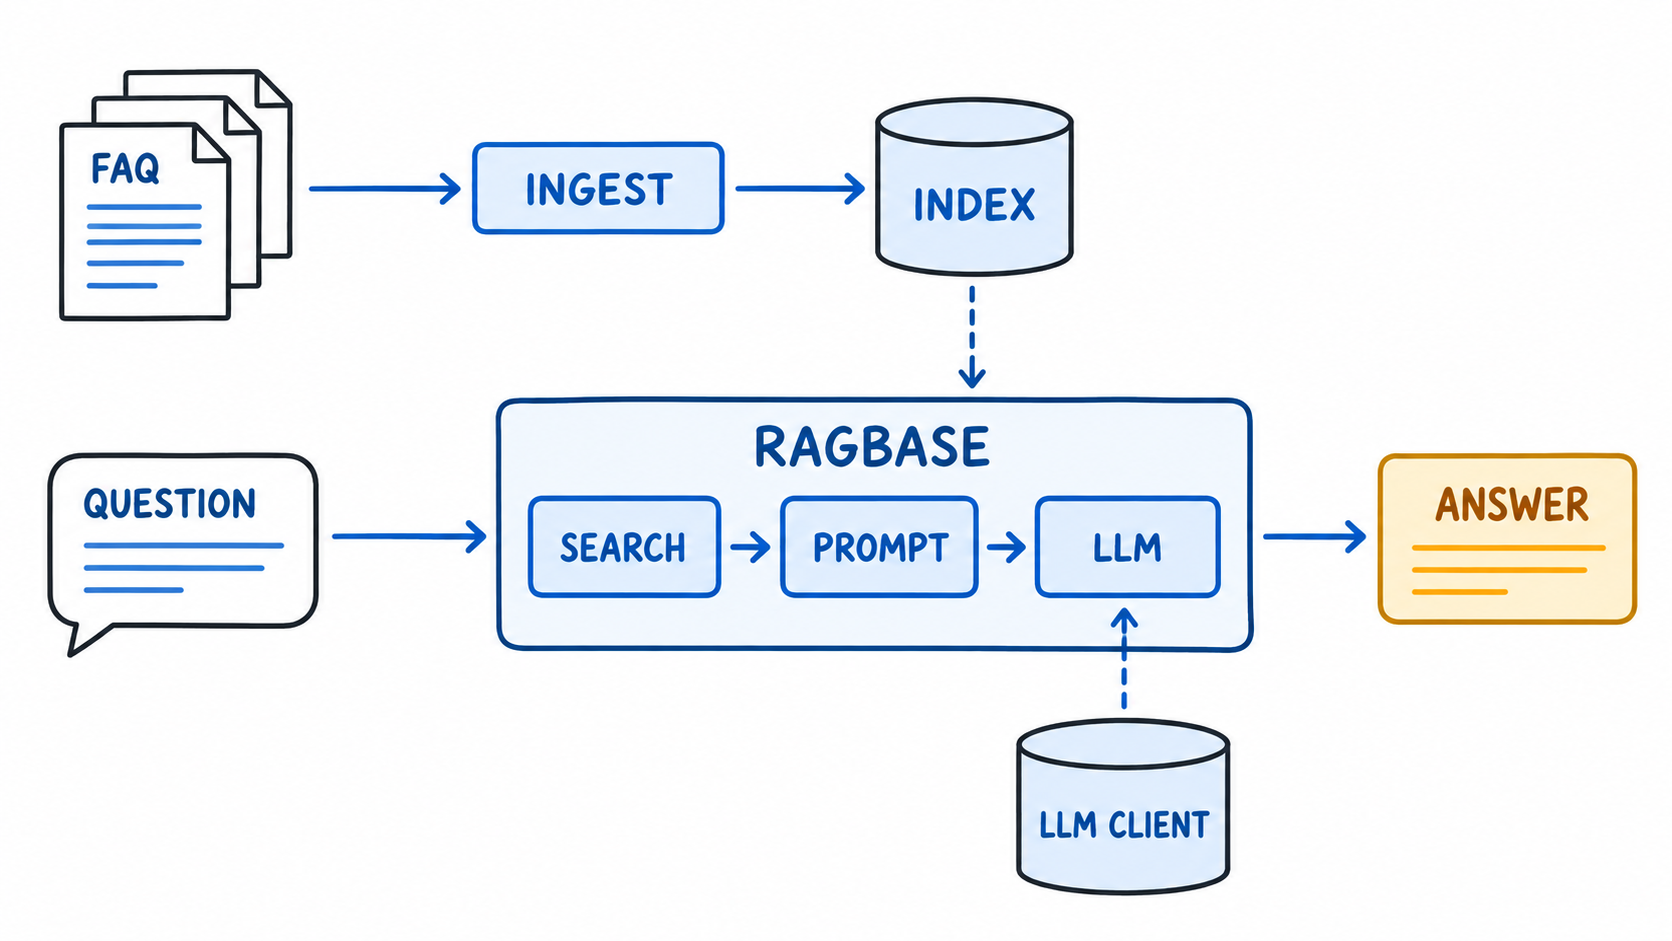

### rag_helper.py

This file contains the RAG logic - the same functions we wrote in the previous lessons, now organized as a class.

We use a class because index and openai_client are currently global variables. Move the functions to a separate file and those globals aren't there anymore. We could import them back, but that ties the file to one specific index and one specific client. That makes the code hard to reuse and adjust.

So we put the dependencies inside a class instead. The index and the LLM client become constructor arguments. Now we can pass any index or client we want when we create the object. And because it's a class, we can subclass it later to override one piece without touching the rest. For example, we can swap OpenAI for a local model.



The index parameter is anything with a search method, whether minsearch, sqlitesearch, or something else. The other four parameters all have defaults. You only pass `course`, `instructions`, `prompt_template`, or `model` when you want to override the default behavior. We swap the index later without touching any of the RAG code.